This notebook demonstrates a parameter-constrained Neural Architecture Search. We'll define a human-engineered baseline model and calculate its parameter budget. Then, we'll use a random search algorithm to find an AI-designed model that strictly stays under the human-engineered model's parameter budget while attempting to achieve a higher validation accuracy on CIFAR-10

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import random
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import matplotlib.ticker as mtick

# device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# loading CIFAR-10
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


Using device: cpu


Defined here is our baseline model. It is a standard 3-layer convolutional neural network. We'll calculate its parameter count to set the hard constraint for the NAS algorithm.

In [9]:
class BaselineModel(nn.Module):
    def __init__(self):
        super(BaselineModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_model = BaselineModel().to(device)
BASELINE_PARAMS = count_parameters(baseline_model)

print(f"Baseline Total Parameters: {BASELINE_PARAMS:,}")


Baseline Total Parameters: 94,986


Next we define the search space for the NAS algorithm. We'll provide a list of potential operations like 3x3 conv, 5x5 conv, and pooling. The AutomatedModel class takes a randomly generated list of these operations and compiles them into a valid PyTorch model.

In [10]:
# search space
AVAILABLE_OPS = ['conv3_16', 'conv3_32', 'conv3_64', 'conv5_16', 'conv5_32', 'pool']

class AutomatedModel(nn.Module):
    def __init__(self, op_list):
        super(AutomatedModel, self).__init__()
        layers = []
        in_channels = 3
        
        for op in op_list:
            if op.startswith('conv3'):
                out_channels = int(op.split('_')[1])
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU())
                in_channels = out_channels
                
            elif op.startswith('conv5'):
                out_channels = int(op.split('_')[1])
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=5, padding=2))
                layers.append(nn.BatchNorm2d(out_channels))
                layers.append(nn.ReLU())
                in_channels = out_channels
                
            elif op == 'pool':
                layers.append(nn.MaxPool2d(2, 2))
                
        self.features = nn.Sequential(*layers)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        final_channels = in_channels if in_channels != 3 else 3
        self.classifier = nn.Linear(final_channels, 10)

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def generate_random_architecture(num_layers=4):
    return [random.choice(AVAILABLE_OPS) for _ in range(num_layers)]


To evaluate the models rapidly, we're training them for 2 epochs. The accuracy after 2 epochs serves as a proxy for how well the models would perform if fully trained.

In [11]:
def proxy_evaluate(model, epochs=2):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    model.train()
    for epoch in range(epochs):
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # quick val
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(testloader):
            if i > 10: break # only check about 1000 images for proxy
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return correct / total


Here is the core NAS algorithm. We generate random architectures, reject any that exceed the BASELINE_PARAMS budget, and evaluate the valid ones using our proxy function.

In [12]:
NUM_SEARCH_ITERATIONS = 100 
best_automated_recipe = None
best_automated_score = 0.0
best_automated_params = 0
search_history = []

print(f"Budget constraint: {BASELINE_PARAMS:,} parameters")

# evaluating baseline proxy score to ensure it's defined for cloud plot
print("Evaluating baseline proxy score")
baseline_proxy_score = proxy_evaluate(baseline_model)

print("\nStarting NAS search...")

for i in range(NUM_SEARCH_ITERATIONS):
    # generate candidate
    candidate_recipe = generate_random_architecture(num_layers=random.randint(3, 6))
    candidate_model = AutomatedModel(candidate_recipe)
    params = count_parameters(candidate_model)
    
    # enforce constraint
    if params > BASELINE_PARAMS:
        continue
        
    # evaluate candidate
    score = proxy_evaluate(candidate_model)
    print(f"Iter {i+1}: Proxy Score {score:.4f} (Params: {params:,})")

    # Store data for plots
    search_history.append({
        'iteration': i + 1,
        'params': params,
        'score': score
    })

    if score > best_automated_score:
        best_automated_score = score
        best_automated_recipe = candidate_recipe
        best_automated_params = params

        # save to text file in case of crash
        with open("best_automated_checkpoint.txt", "w") as f:
            f.write(f"Best Score: {best_automated_score:.4f}\n")
            f.write(f"Params: {best_automated_params}\n")
            f.write(f"Recipe: {best_automated_recipe}\n")

print("\nSearch complete")


Budget constraint: 94,986 parameters.
Evaluating baseline proxy score

Starting NAS search...
Iter 1: Proxy Score 0.5490 (Params: 39,402)
Iter 2: Proxy Score 0.5107 (Params: 37,834)
Iter 3: Proxy Score 0.4389 (Params: 3,002)
Iter 4: Proxy Score 0.4084 (Params: 24,874)
Iter 5: Proxy Score 0.4503 (Params: 31,866)
Iter 6: Proxy Score 0.5043 (Params: 45,930)
Iter 7: Proxy Score 0.5490 (Params: 39,722)
Iter 9: Proxy Score 0.5092 (Params: 41,178)
Iter 10: Proxy Score 0.4766 (Params: 55,882)
Iter 11: Proxy Score 0.4716 (Params: 12,730)
Iter 12: Proxy Score 0.4908 (Params: 24,202)
Iter 13: Proxy Score 0.5050 (Params: 39,722)
Iter 14: Proxy Score 0.4737 (Params: 62,282)
Iter 15: Proxy Score 0.5057 (Params: 28,746)
Iter 16: Proxy Score 0.4801 (Params: 24,410)
Iter 17: Proxy Score 0.3388 (Params: 3,770)
Iter 18: Proxy Score 0.5135 (Params: 90,714)
Iter 19: Proxy Score 0.5497 (Params: 59,178)
Iter 20: Proxy Score 0.4240 (Params: 5,786)
Iter 21: Proxy Score 0.5739 (Params: 24,858)
Iter 22: Proxy Sc

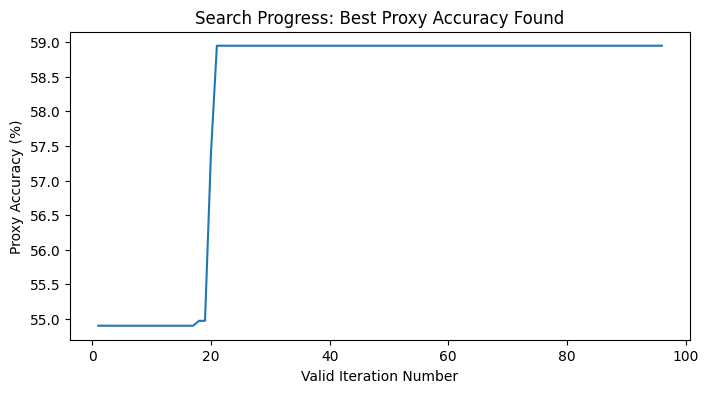

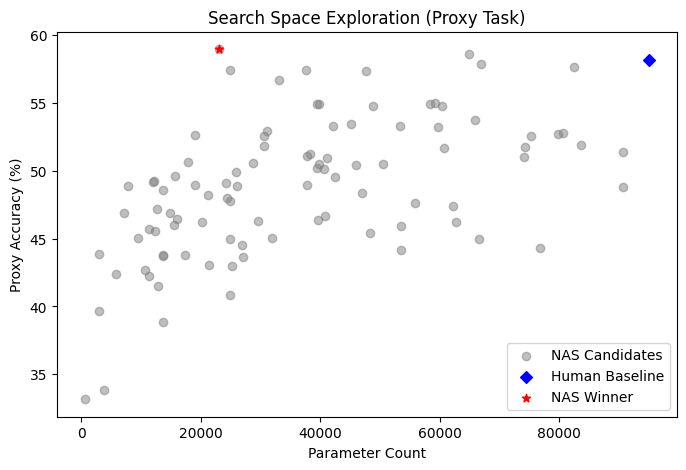

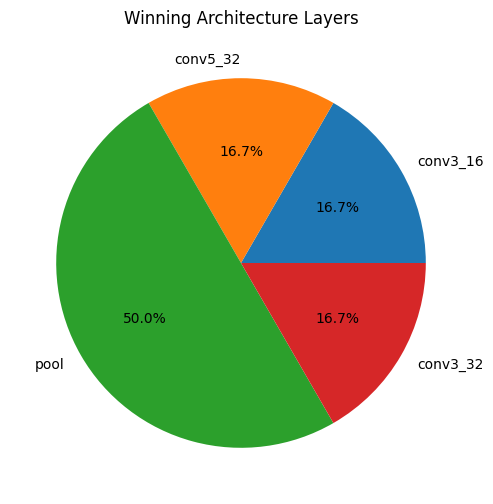

In [13]:
# plot 1: search progress
plt.figure(figsize=(8, 4))
scores = [h['score'] * 100 for h in search_history]
running_max = []
current_max = 0
for s in scores:
    if s > current_max: current_max = s
    running_max.append(current_max)

plt.plot(range(1, len(running_max) + 1), running_max)
plt.title('Search Progress: Best Proxy Accuracy Found')
plt.xlabel('Valid Iteration Number')
plt.ylabel('Proxy Accuracy (%)')
plt.show()

# plot 2: search space cloud
plt.figure(figsize=(8, 5))
all_params = [h['params'] for h in search_history]
all_scores = [h['score'] * 100 for h in search_history]

plt.scatter(all_params, all_scores, color='gray', alpha=0.5, label='NAS Candidates')
plt.scatter(BASELINE_PARAMS, baseline_proxy_score * 100, color='blue', label='Human Baseline', marker='D')
plt.scatter(best_automated_params, best_automated_score * 100, color='red', label='NAS Winner', marker='*')

plt.title('Search Space Exploration (Proxy Task)')
plt.xlabel('Parameter Count')
plt.ylabel('Proxy Accuracy (%)')
plt.legend()
plt.show()

# plot 3: layer composition
plt.figure(figsize=(6, 6))
op_counts = Counter(best_automated_recipe)
plt.pie(op_counts.values(), labels=op_counts.keys(), autopct='%1.1f%%')
plt.title('Winning Architecture Layers')
plt.show()


We take the baseline and our best automated model and train them properly to compare their true performance and efficiency

In [14]:
def fully_train_and_evaluate(model, name, epochs=25):
    print(f"\n--- Training {name} for {epochs} epochs ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    steps_per_epoch = len(trainloader)
    scheduler = lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=steps_per_epoch, epochs=epochs)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step() 
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} Loss: {running_loss/len(trainloader):.4f}")
        
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    accuracy = 100. * correct / total
    print(f">>> {name} Final Accuracy: {accuracy:.2f}%")
    return accuracy

FULL_EPOCHS = 25 
baseline_acc = fully_train_and_evaluate(baseline_model, "Baseline", FULL_EPOCHS)
winning_automated_model = AutomatedModel(best_automated_recipe)
automated_acc = fully_train_and_evaluate(winning_automated_model, "Automated", FULL_EPOCHS)

results = pd.DataFrame({
    "Model": ["Baseline", "NAS Optimized"],
    "Parameters": [BASELINE_PARAMS, best_automated_params],
    "Test Accuracy (%)": [baseline_acc, automated_acc],
    "Efficiency (Acc / 10k Params)": [
        (baseline_acc / BASELINE_PARAMS) * 10000,
        (automated_acc / best_automated_params) * 10000
    ]
})
display(results)



--- Training Baseline for 25 epochs ---
Epoch 1/25 Loss: 0.9632
Epoch 2/25 Loss: 0.9210
Epoch 3/25 Loss: 0.8973
Epoch 4/25 Loss: 0.8840
Epoch 5/25 Loss: 0.8568
Epoch 6/25 Loss: 0.8262
Epoch 7/25 Loss: 0.7862
Epoch 8/25 Loss: 0.7484
Epoch 9/25 Loss: 0.7059
Epoch 10/25 Loss: 0.6759
Epoch 11/25 Loss: 0.6460
Epoch 12/25 Loss: 0.6153
Epoch 13/25 Loss: 0.5961
Epoch 14/25 Loss: 0.5694
Epoch 15/25 Loss: 0.5507
Epoch 16/25 Loss: 0.5276
Epoch 17/25 Loss: 0.5066
Epoch 18/25 Loss: 0.4854
Epoch 19/25 Loss: 0.4678
Epoch 20/25 Loss: 0.4541
Epoch 21/25 Loss: 0.4406
Epoch 22/25 Loss: 0.4263
Epoch 23/25 Loss: 0.4182
Epoch 24/25 Loss: 0.4086
Epoch 25/25 Loss: 0.4100
>>> Baseline Final Accuracy: 82.84%

--- Training Automated for 25 epochs ---
Epoch 1/25 Loss: 1.7697
Epoch 2/25 Loss: 1.3588
Epoch 3/25 Loss: 1.1991
Epoch 4/25 Loss: 1.1125
Epoch 5/25 Loss: 1.0441
Epoch 6/25 Loss: 0.9885
Epoch 7/25 Loss: 0.9523
Epoch 8/25 Loss: 0.9191
Epoch 9/25 Loss: 0.8876
Epoch 10/25 Loss: 0.8581
Epoch 11/25 Loss: 0.8339

,Model,Parameters,Test Accuracy (%),Efficiency (Acc / 10k Params)
0,Baseline,94986,82.84,8.721285
1,NAS Optimized,23018,75.46,32.783039


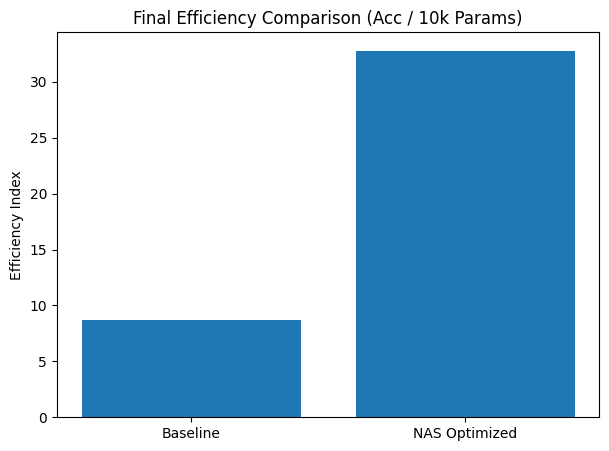

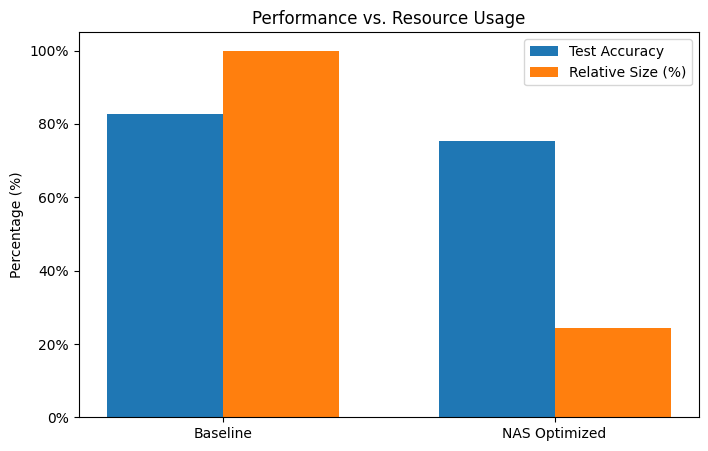

In [16]:
models = results['Model'].tolist()
eff_values = [results.iloc[0]['Efficiency (Acc / 10k Params)'], 
              results.iloc[1]['Efficiency (Acc / 10k Params)']]

# plot 1: final efficiency
plt.figure(figsize=(7, 5))
plt.bar(models, eff_values)
plt.ylabel('Efficiency Index')
plt.title('Final Efficiency Comparison (Acc / 10k Params)')
plt.show()

# plot 2: accuracy vs resource usage
norm_params = [100.0, (best_automated_params / BASELINE_PARAMS) * 100.0]
acc_vals = [baseline_acc, automated_acc]
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, acc_vals, width, label='Test Accuracy')
ax.bar(x + width/2, norm_params, width, label='Relative Size (%)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Performance vs. Resource Usage')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()
